In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import yaml
import os
#erc-karst package to pip install
import karstnet as kn # Karstnet-ERC version (pip install .)
import kntools as kt


## Load database

In [2]:
#load graph
cavename = 'GouffreDejaVu'

#extract metadata from google sheet
metadata = kt.get_metadata(cavename)

# kt.update_metadata_git(cavename)

In [3]:
progress_folder = 'c:/Users/celia/OneDrive - unine.ch/network_data_working_folder/2_in_progress'

#find automatically the number associated with the cavename
list_folder = os.listdir('../data')
# number = [item.split('_')[0] for item in list_folder if cavename in item][0]

# Load the SQL database
# path_dataset = f'../data/{number}_{cavename}/sql_database/{cavename}.sql'
path_dataset = f'{progress_folder}/{metadata['number']}_{cavename}/original_data/sql_data/{cavename}.sql'

# Create graph (do not remove flagged edges yet)
print('Loading therion sql data')
G  = kn.io_func.networkx_from_therion_sql(path_dataset) 

# Add metadata to graph
G.graph = metadata

Loading therion sql data
Therion Import -- Importing all links (including splays) -- 0.006897926330566406s
Therion Import -- Importing all nodes data (including splays) -- 0.00718379020690918s
Therion Import -- Create initial graph with all the data points (including splays) -- 0.008118391036987305s
Therion Import -- Combine Stations with identical x,y,z -- 0.009980916976928711s
0/33 unique positions
Therion Import -- Rename nodes -- 0.010488033294677734s
0/33 nodes to rename
Therion Import -- concatenate old ic in a dictionnary -- 0.010545969009399414s
Therion Import -- Relabel nodes -- 0.010570526123046875s
Therion Import -- remove self links -- 0.011663675308227539s
Therion Import --add dictionnaries to graph -- 0.011699914932250977s
Therion Import -- add splays -- 0.01170969009399414s
Therion Import -- add fulladdress -- 0.012091398239135742s
Therion Import -- add flags
Therion Import -- add sql ids -- 0.015062093734741211s
Therion Import -- remove isolated nodes -- 0.0151691436767

## Add conduit geometry

no lrud data to download from .th file
Extracting dimension from SQL


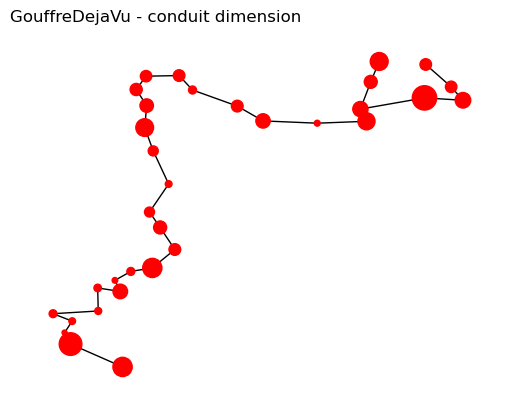

In [ ]:
# ADD GEOMETRY
#################

# !! Modify function to add both dimension from splays and lrud...

# kt.full_add_geom(G,cavename, metadata)

if metadata['original_format'].lower() in ('toporobot','vtopo', 'compass','ghtopo', 'shp_compass', 'unknown_lrud'):
    csdim_from_th = f'{progress_folder}/{metadata['number']}_{cavename}/original_data/therion_project/{cavename}_convert.th'
    print(f'extracting geometry data from :{ csdim_from_th}')
else:
    print('no lrud data to download from .th file')
    csdim_from_th = None

#todo:
#1. normalize vector when calculating main direction -- done 30 july 2024 -- but it change the plan and made it all perpendicular
#2. solve toporobot exception for vertical edges when calculating lrud_splays
#3. rename splay into splays_lrud and splays_shot
#4. calculate splays_lrud for therion data with splays (to see how they do)

#calculate geometry based on splays
#geommean_radius, cs_width, cs_height, projected_splays_u, projected_splays_v = ux.calc_conduit_dimensions(G, output = 'all')
print('Extracting dimension from SQL')
cs_dimension = kn.geom.calc_conduit_dimensions(G, output = 'csdim')
cs_dimension = {k: v for k, v in cs_dimension.items() if not (v[0] == 0 and v[1] == 0)}

if csdim_from_th is not None:
    print('full_sql_import -- Extracting dimension from therion file')
    cs_dimension_lrud = kn.geom.calc_csdim_from_th(G, csdim_from_th,metadata['units'])
    #remove node with 0 with and 0 height:
    cs_dimension_lrud = {k: v for k, v in cs_dimension_lrud.items() if not (v[0] == 0 and v[1] == 0)}
    nx.set_node_attributes(G, cs_dimension_lrud, 'csdim')  
#calcuate geomtery based on LRUD

#ADD GEOMETRY INFO ON THE NODES
#cross-sectional dimensions: width and height in the cross-sectional plan of the conduit perpendicular to the conduit direction
#nx.set_node_attributes(G, geommean_radius, 'geommean_radius') 
nx.set_node_attributes(G, cs_dimension, 'csdim') 

#exemple PLOT WITH WEIGHTED NODE GEOMETRY
node_sizes = []
labels = {}
for n in G.nodes:
    if G.nodes('csdim')[n] is not None:
        node_sizes.append( nx.get_node_attributes(G,'csdim')[n][0]*30 )
    else:
        node_sizes.append( 0.0 )

plt.figure()
ax = plt.gca()
ax.set_title(f'{cavename} - conduit dimension', loc='left',ha='left', wrap=True )
nx.draw(G,kn.utils.get_pos2d(G),node_size=node_sizes ,with_labels=False, node_color='red', ax=ax)

In [5]:
# CLEAN GRAPH
#################
# If H is not fully cleaned up, update the yaml file and re-run the code
H,I = kt.full_flag_G( G,
                    cavename,
                    correction_manual='c:/Users/celia/OneDrive - unine.ch/network_data_working_folder/2_in_progress/caves_info.yaml',
                    correction_auto=None)

full_sql_import -- Cleaning graph
full_clean_G --- there is no correction in yaml file for this cave
There is  1 connected components in the graph with additional edges
it works


In [6]:
kt.full_save_outputs(G,H,I,cavename)

full_save_outputs -- Saving graph in yaml format and csv format to working folder and github
There is  1 connected components in the original graph


AttributeError: 'NoneType' object has no attribute 'is_directed'